# **Side Effects Projection Network Analysis**

# Import Libraries

In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

# Load Network

In [2]:
# Load the network edge list and node attributes
df_edges = pd.read_csv('../data/processed/side-effect-projection-edges.csv')
df_nodes = pd.read_csv('../data/processed/bipartite-network-nodes.csv', sep=';')

# Create the network
G = nx.from_pandas_edgelist(df_edges, source='source', target='target')

# Number of Nodes and Edges

In [3]:
# Compute the number of nodes and edges
print(f'Number of nodes: {G.number_of_nodes()}')
print(f'Number of edges: {G.number_of_edges()}')

Number of nodes: 131
Number of edges: 1427


# Degree Distributions

## Descriptive Analysis

In [4]:
# Transform the degree list into a DataFrame
df_degrees = pd.DataFrame(
    data=G.degree(), columns=['side effect', 'degree']
)

# Sort the nodes by descending degree value
df_degrees = df_degrees \
    .sort_values(by='degree', ascending=False) \
    .reset_index(drop=True)

# Print the degree distribution statistical description
print('Degree distribution statistics:')
print(df_degrees.describe())

# Print the top-5 and bottom-5 nodes by degree
print(f'\nTop-5 nodes by degree: \n{df_degrees.head(5)}')
print(f'\nBottom-5 nodes by degree: \n{df_degrees.tail(5)}')

Degree distribution statistics:
          degree
count  131.00000
mean    21.78626
std     20.95857
min      3.00000
25%      9.50000
50%     14.00000
75%     25.00000
max    109.00000

Top-5 nodes by degree: 
    side effect  degree
0     dizziness     109
1        nausea     105
2      headache      90
3  constipation      84
4      vomiting      84

Bottom-5 nodes by degree: 
                                      side effect  degree
126                                metallic taste       3
127                                  bitter taste       3
128  paresthesia (tingling or pricking sensation)       3
129   systemic hypertension (high blood pressure)       3
130                               cns stimulation       3


## Preparation for Plots

In [5]:
# Compute degree sequence
degree_sequence = np.array([d for _, d in G.degree()])

# Compute degree frequencies
degree_values, degree_counts = np.unique(degree_sequence, return_counts=True)

# Compute degree probabilities
degree_prob = degree_counts / degree_counts.sum()

# Compute complementary cumulative distribution function
ccdf = np.cumsum(degree_prob[::-1])[::-1]

## Linear Plot

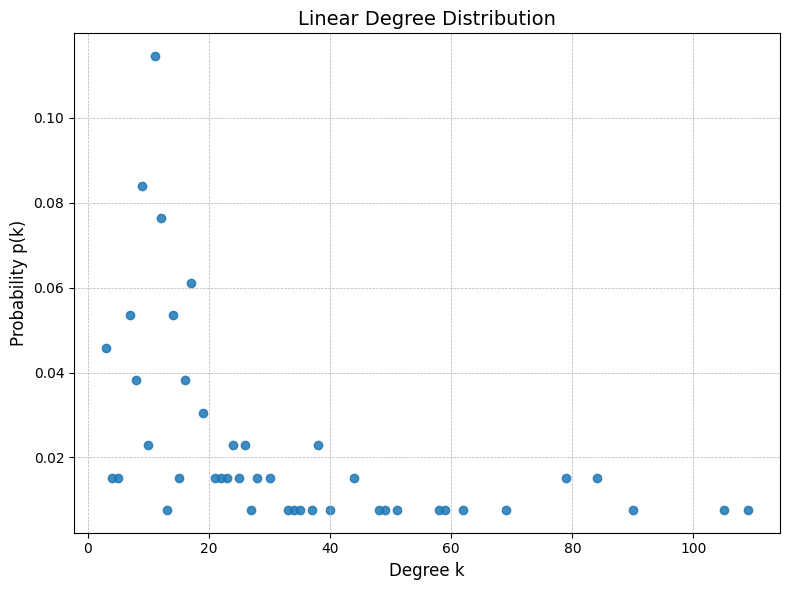

In [6]:
# Scatter plot visualization
plt.figure(figsize=(8, 6))
plt.scatter(x=degree_values, y=degree_prob, alpha=0.85)

# Plot configuration
plt.title('Linear Degree Distribution', fontsize=14)
plt.xlabel('Degree k', fontsize=12)
plt.ylabel('Probability p(k)', fontsize=12)
plt.grid(True, which='both', ls='--', lw=0.5)
plt.tight_layout()
plt.show()

## Log-log Plot

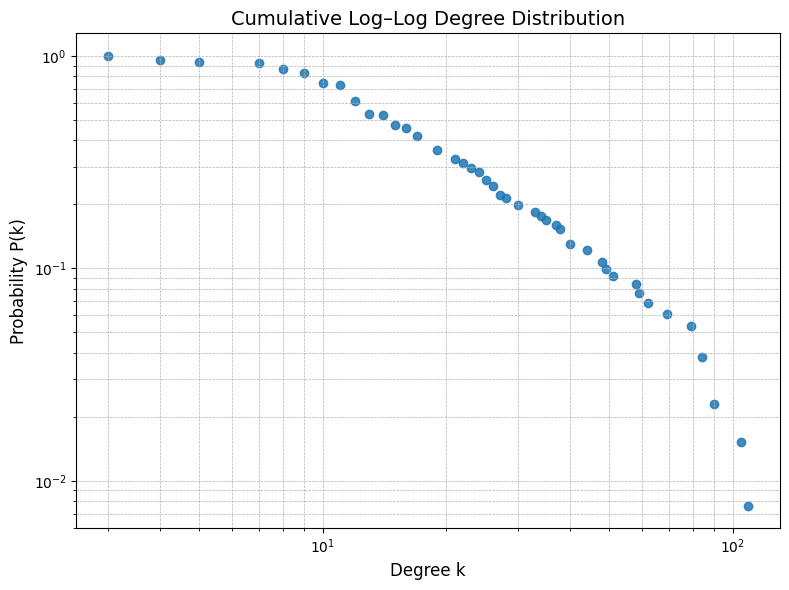

In [7]:
# Scatter plot visualization on log-log scale
plt.figure(figsize=(8, 6))
plt.scatter(x=degree_values, y=ccdf, alpha=0.85)
plt.xscale('log')
plt.yscale('log')

# Plot configuration 
plt.title('Cumulative Log–Log Degree Distribution', fontsize=14)
plt.xlabel('Degree k', fontsize=12)
plt.ylabel('Probability P(k)', fontsize=12)
plt.grid(True, which='both', ls='--', lw=0.5)
plt.tight_layout()
plt.show()

# Connected Components

In [8]:
# Compute the number of connected components
connected_components = list(nx.connected_components(G))
print(f'Number of connected components: {len(connected_components)}')

# Print the connected components size statistical description
cc_sizes = [len(c) for c in connected_components]
cc_sizes_series = pd.Series(cc_sizes)
print('\nConnected components size statistics:')
print(cc_sizes_series.describe())

# Print the diameter of the connected component
print(f'\nDiameter of the connected component: {nx.diameter(G)}')

Number of connected components: 1

Connected components size statistics:
count      1.0
mean     131.0
std        NaN
min      131.0
25%      131.0
50%      131.0
75%      131.0
max      131.0
dtype: float64

Diameter of the connected component: 3


# Clustering Coefficient

In [9]:
print(f'Average clustering coefficient: {nx.average_clustering(G)}')

Average clustering coefficient: 0.8319129633783555


# Centralities

In [10]:
# Create a DataFrame with the side effects and their respective severities
df_side_effects = pd.DataFrame(data=G.nodes(), columns=['id'])
df_side_effects = \
    pd.merge(left=df_nodes, right=df_side_effects, how='left', on='id') \
    .query('type == "side effect"') \
    .reset_index(drop=True) \
    [['id', 'severity']]

## Betweenness

In [11]:
# Compute the betweenness centrality for the giant component nodes
betweenness_centrality = nx.betweenness_centrality(G=G)
df_betweenness_centrality = pd.DataFrame(
    data=betweenness_centrality.items(), columns=['id', 'betweenness_centrality']
)

# Join the metric values in the side effects and severities DataFrame
df_side_effects = pd.merge(
    left=df_side_effects, right=df_betweenness_centrality, how='inner', on='id'
)

# Create a DataFrame only with the data to be printed
df_print = df_side_effects.copy() \
    .sort_values(by='betweenness_centrality', ascending=False) \
    .reset_index(drop=True) \
    [['id', 'severity', 'betweenness_centrality']]

# Print the top-5 and bottom-5 most important nodes
print(f'Top-5 nodes by betweenness: \n{df_print.head(5)}')
print(f'\nBottom-5 nodes by betweenness: \n{df_print.tail(5)}')

Top-5 nodes by betweenness: 
           id  severity  betweenness_centrality
0   dizziness      mild                0.147632
1      nausea      mild                0.116659
2    headache      mild                0.089031
3  drowsiness  moderate                0.083710
4    vomiting  moderate                0.060363

Bottom-5 nodes by betweenness: 
                               id  severity  betweenness_centrality
125  apnea (absence of breathing)    severe                     0.0
126            respiratory arrest    severe                     0.0
127          circulatory disorder    severe                     0.0
128                         shock    severe                     0.0
129  muscle coordination impaired  moderate                     0.0


## Closeness

In [12]:
# Compute the closeness centrality for the giant component nodes
closeness_centrality = nx.closeness_centrality(G=G)
df_closeness_centrality = pd.DataFrame(
    data=closeness_centrality.items(), columns=['id', 'closeness_centrality']
)

# Join the metric values in the side effects and severities DataFrame
df_side_effects = pd.merge(
    left=df_side_effects, right=df_closeness_centrality, how='inner', on='id'
)

# Create a DataFrame only with the data to be printed
df_print = df_side_effects.copy() \
    .sort_values(by='closeness_centrality', ascending=False) \
    .reset_index(drop=True) \
    [['id', 'severity', 'closeness_centrality']]

# Print the top-5 and bottom-5 most important nodes
print(f'Top-5 nodes by closeness: \n{df_print.head(5)}')
print(f'\nBottom-5 nodes by closeness: \n{df_print.tail(5)}')

Top-5 nodes by closeness: 
             id  severity  closeness_centrality
0     dizziness      mild              0.860927
1        nausea      mild              0.838710
2      headache      mild              0.764706
3  constipation      mild              0.738636
4      vomiting  moderate              0.738636

Bottom-5 nodes by closeness: 
                                              id  severity  \
125                          withdrawal symptoms  moderate   
126                                   nightmares  moderate   
127                             cold extremities      mild   
128                              cns stimulation    severe   
129  systemic hypertension (high blood pressure)  moderate   

     closeness_centrality  
125              0.445205  
126              0.442177  
127              0.442177  
128              0.371429  
129              0.371429  


## Degree

In [13]:
# Compute the degree centrality for the giant component nodes
degree_centrality = nx.degree_centrality(G=G)
df_degree_centrality = pd.DataFrame(
    data=degree_centrality.items(), columns=['id', 'degree_centrality']
)

# Join the metric values in the side effects and severities DataFrame
df_side_effects = pd.merge(
    left=df_side_effects, right=df_degree_centrality, how='inner', on='id'
)

# Create a DataFrame only with the data to be printed
df_print = df_side_effects.copy() \
    .sort_values(by='degree_centrality', ascending=False) \
    .reset_index(drop=True) \
    [['id', 'severity', 'degree_centrality']]

# Print the top-5 and bottom-5 most important nodes
print(f'Top-5 nodes by degree: \n{df_print.head(5)}')
print(f'\nBottom-5 nodes by degree: \n{df_print.tail(5)}')

Top-5 nodes by degree: 
             id  severity  degree_centrality
0     dizziness      mild           0.838462
1        nausea      mild           0.807692
2      headache      mild           0.692308
3  constipation      mild           0.646154
4      vomiting  moderate           0.646154

Bottom-5 nodes by degree: 
                                               id  severity  degree_centrality
125  paresthesia (tingling or pricking sensation)      mild           0.023077
126                               cns stimulation    severe           0.023077
127                                metallic taste      mild           0.023077
128                                  bitter taste      mild           0.023077
129   systemic hypertension (high blood pressure)  moderate           0.023077


# Communities

## Detection

In [14]:
# Find the communities using the Greedy algorithm
# https://networkx.org/documentation/stable/auto_examples/drawing/plot_clusters.html
communities = nx.community.greedy_modularity_communities(G)
print(f'Number of communities: {len(communities)}')

# Create a DataFrame to store the community labels
df_communities = pd.DataFrame(columns=['id', 'community'])

# Input the data into the DataFrame
for i in range (len(communities)):
    nodes = list(communities[i])
    df_nodes = pd.DataFrame(data=nodes, columns=['id'])
    df_nodes['community'] = i

    df_communities = pd.concat(objs=[df_communities, df_nodes])

# Join community labels in the side effects DataFrame
df_side_effects = pd.merge(
    left=df_side_effects, right=df_communities, how='left', on='id'
)

# Print the number of nodes per community
print(df_side_effects.value_counts(subset='community'))

Number of communities: 5
community
0    42
1    37
2    31
3    15
4     5
Name: count, dtype: int64


In [15]:
df_side_effects \
    .query('community == 0') \
    [['id', 'severity']] \
    .sort_values(by='severity') \
    .reset_index(drop=True)

,id,severity
0,blurred vision,mild
1,fainting,mild
2,numbness in mouth,mild
3,sleep disturbance,mild
4,metallic taste,mild
5,bitter taste,mild
6,urine discoloration,mild
7,flushing of skin,mild
8,flu-like symptoms,mild
9,runny nose,mild


In [16]:
df_side_effects \
    .query('community == 1') \
    [['id', 'severity']] \
    .sort_values(by='severity') \
    .reset_index(drop=True)

,id,severity
0,confusion,mild
1,tremors,mild
2,decreased appetite,mild
3,cold extremities,mild
4,low sexual desire,mild
5,irritation,mild
6,weight gain,mild
7,increased prolactin level in blood,mild
8,edema (swelling),mild
9,tiredness,mild


In [17]:
df_side_effects \
    .query('community == 2') \
    [['id', 'severity']] \
    .sort_values(by='severity') \
    .reset_index(drop=True)

,id,severity
0,chalky taste,mild
1,muscle pain,mild
2,stomach pain/epigastric pain,mild
3,paresthesia (tingling or pricking sensation),mild
4,joint pain,mild
5,common cold,mild
6,nasal discomfort,mild
7,skin rash,mild
8,injection site pain,mild
9,fatigue,mild


In [18]:
df_side_effects \
    .query('community == 3') \
    [['id', 'severity']] \
    .sort_values(by='severity') \
    .reset_index(drop=True)

,id,severity
0,nausea,mild
1,dizziness,mild
2,double vision,mild
3,application site redness,mild
4,agitation,moderate
5,rigidity,moderate
6,respiratory depression,moderate
7,muscle rigidity,moderate
8,irregular heartbeats,moderate
9,memory loss,severe


In [19]:
df_side_effects \
    .query('community == 4') \
    [['id', 'severity']] \
    .sort_values(by='severity') \
    .reset_index(drop=True)

,id,severity
0,rash,mild
1,taste change,mild
2,hallucination,moderate
3,viral infection,moderate
4,respiratory tract infection,severe


## Network Plot

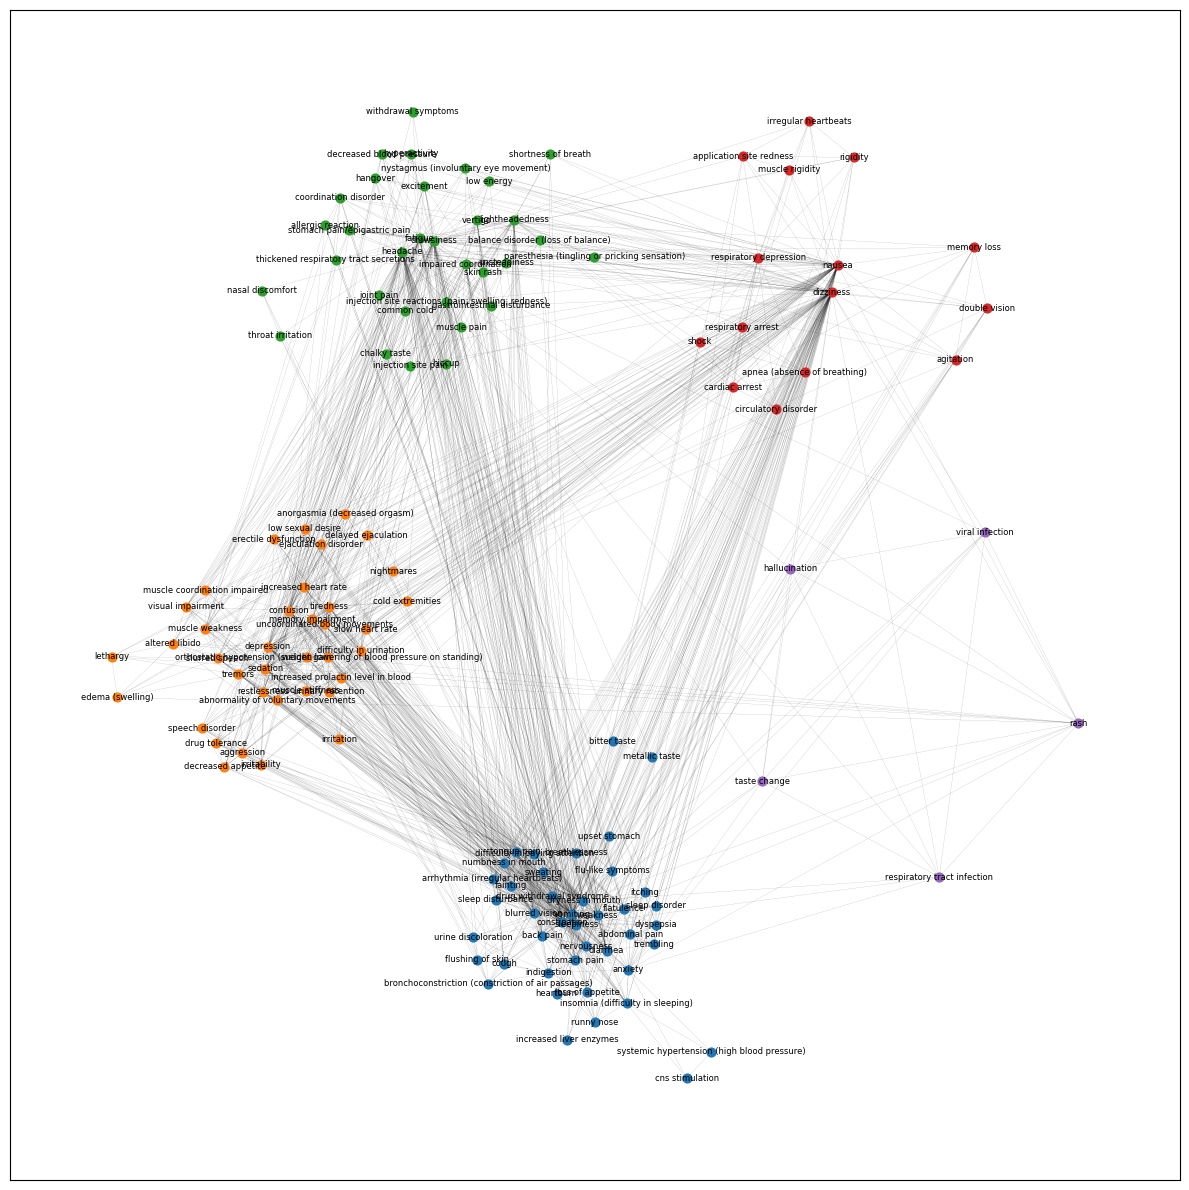

In [20]:
# Compute positions for the node clusters as if they were themselves nodes in a
# supergraph using a larger scale factor
supergraph = nx.cycle_graph(len(communities))
superpos = nx.spring_layout(supergraph, scale=2, seed=429)

# Use the "supernode" positions as the center of each node cluster
centers = list(superpos.values())
pos = {}
for center, comm in zip(centers, communities):
    pos.update(nx.spring_layout(nx.subgraph(G, comm), center=center, seed=1430))
plt.figure(figsize=(12, 12))

# Nodes colored by cluster
colors = ('tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown', 'tab:pink')
for nodes, color in zip(communities, colors):
    nx.draw_networkx_nodes(G, pos=pos, nodelist=nodes, node_color=color, node_size=40)
nx.draw_networkx_edges(G, pos=pos, width=0.05)

# Add node labels
nx.draw_networkx_labels(G, pos=pos, font_size=6)
# texts = [plt.text(x, y, s, fontsize=6) for s, (x, y) in pos.items()]
# adjust_text(texts)

# Plot network
plt.tight_layout()
plt.show()

## Severity Distributions

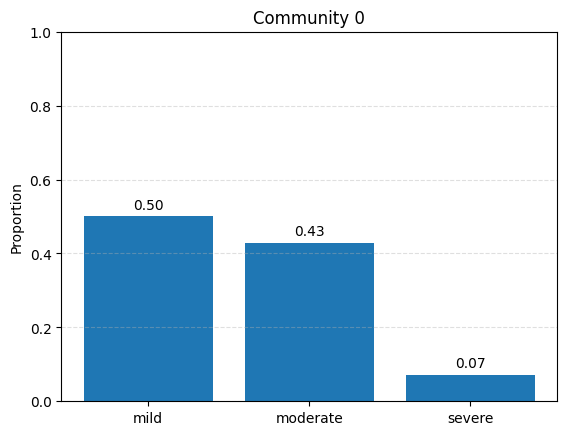

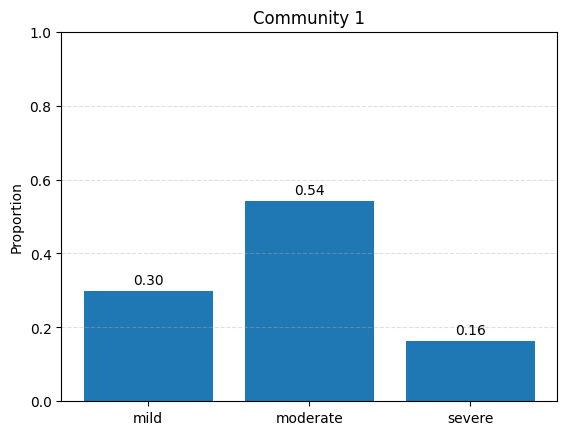

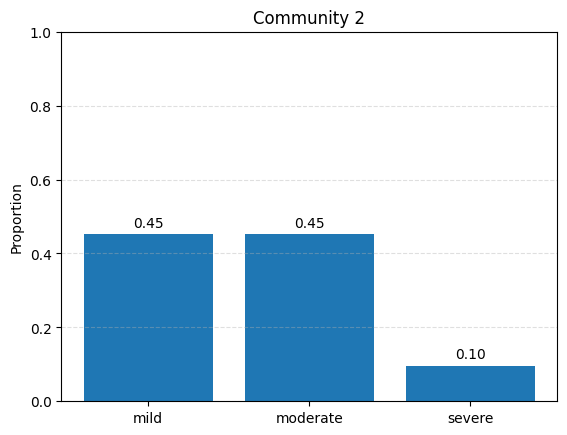

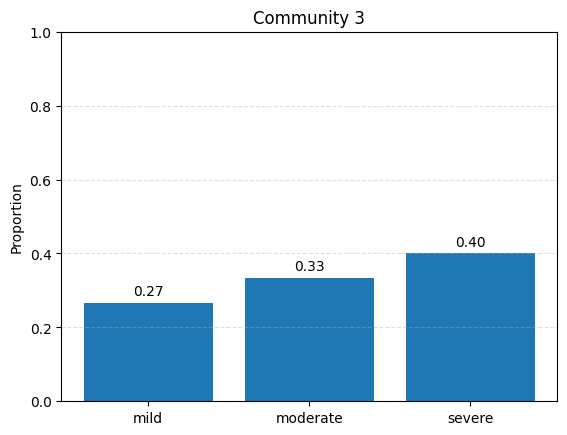

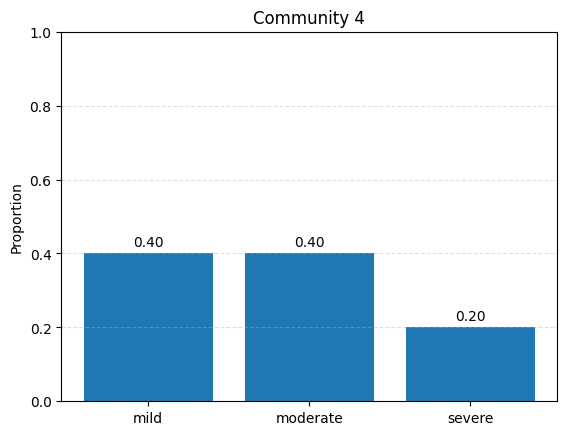

In [21]:
# Plot the severity distribution by community
for i in range (len(communities)):
    df_severities = df_side_effects \
        .query(f'community == {i}') \
        .value_counts(subset='severity', normalize=True) \
        .reset_index() \
        .sort_values(by='severity')
    
    # Create barplot
    plt.figure()
    plt.bar(x=df_severities['severity'], height=df_severities['proportion'])
    plt.ylim(0, 1)

    # Add value labels
    for x, y in zip(df_severities['severity'], df_severities['proportion']):
        plt.text(x, y + 0.02, f'{y:.2f}', ha='center')
    
    # Add labels and gridlines
    plt.title(f'Community {i}')
    # plt.xlabel('Severity')
    plt.ylabel('Proportion')
    plt.grid(axis='y', linestyle='--', alpha=0.4)

    plt.show()

## Human Body Systems

In [22]:
body_systems = {
    'cardiovascular system': [
        'systemic hypertension',
        'arrhythmia (irregular heartbeat)',
        'irregular heartbeats',
        'cardiac arrest',
        'circulatory disorder',
        'shock',
        'decreased blood pressure',
        'increased heart rate',
        'orthostatic hypotension',
        'cold extremities',
        'slow heart rate',
        'edema (swelling)',
    ],
    'digestive system': [
        'constipation',
        'dryness in mouth',
        'vomiting',
        'indigestion',
        'loss of appetite',
        'heartburn',
        'stomach pain',
        'abdominal pain',
        'dyspepsia',
        'flatulence',
        'diarrhea',
        'increased liver enzymes',
        'upset stomach',
        'bitter taste',
        'metallic taste',
        'tongue pain',
        'taste change',
        'hiccup',
        'stomach/epigastric pain',
        'gastrointestinal disturbance',
        'chalky taste',
        'decreased appetite',
        'nausea',
    ],
    'immune system': [
        'flu-like symptoms',
        'viral infection',
        'common cold',
        'allergic reaction',
    ],
    'endocrine system': [
        'increased prolactin levels',
        'weight gain',
    ],
    'integumentary system': [
        'itching',
        'flushing of skin',
        'rash',
        'skin rash',
        'injection site pain',
        'irritation',
        'application site redness',
    ],
    'musculoskeletal system': [
        'back pain',
        'rigidity',
        'muscle rigidity',
        'joint pain',
        'muscle pain',
        'muscle weakness',
        'muscle stiffness',
    ],
    'nervous system': [
        'blurred vision',
        'weakness',
        'nervousness',
        'sleepiness',
        'sleep disorder',
        'anxiety',
        'trembling',
        'sweating',
        'insomnia',
        'difficulty paying attention',
        'drug withdrawal syndrome',
        'cns stimulation',
        'sleep disturbance',
        'numbness in mouth',
        'fainting',
        'hallucination',
        'dizziness',
        'double vision',
        'agitation',
        'memory loss',
        'drowsiness',
        'lightheadedness',
        'impaired coordination',
        'headache',
        'fatigue',
        'vertigo',
        'balance disorder',
        'unsteadiness',
        'paresthesia',
        'nystagmus',
        'low energy',
        'excitement',
        'hyperactivity',
        'hangover',
        'withdrawal symptoms',
        'coordination disorder',
        'confusion',
        'uncoordinated body movements',
        'depression',
        'tiredness',
        'memory impairment',
        'sedation',
        'drug tolerance',
        'restlessness',
        'speech disorder',
        'tremors',
        'abnormal voluntary movements',
        'aggression',
        'irritability',
        'nightmares',
        'slurred speech',
        'lethargy',
        'visual impairment',
        'muscle coordination impaired',
    ],
    'respiratory system': [
        'breathlessness',
        'cough',
        'runny nose',
        'bronchoconstriction',
        'respiratory tract infection',
        'respiratory depression',
        'apnea (absence of breathing)',
        'respiratory arrest',
        'thickened respiratory secretions',
        'nasal discomfort',
        'throat irritation',
        'shortness of breath',
    ],
    'reproductive system': [
        'delayed ejaculation',
        'low sexual desire',
        'anorgasmia',
        'altered libido',
        'ejaculation disorder',
        'erectile dysfunction',
    ],
    'urinary system': [
        'urine discoloration',
        'difficulty in urination',
        'urinary retention',
    ]
}


In [23]:
df_body_systems = pd.DataFrame([
    {'body_system': system, 'id': effect}
    for system, effects in body_systems.items()
    for effect in effects
])

df_side_effects = pd.merge(
    left=df_side_effects, right=df_body_systems, how='left', on='id'
)

In [24]:
df_side_effects.query('community == 0').value_counts(subset='body_system')

body_system
digestive system          16
nervous system            13
respiratory system         3
integumentary system       2
immune system              1
musculoskeletal system     1
urinary system             1
Name: count, dtype: int64

In [25]:
df_side_effects.query('community == 1').value_counts(subset='body_system')

body_system
nervous system            17
reproductive system        5
cardiovascular system      4
musculoskeletal system     2
urinary system             2
integumentary system       1
digestive system           1
endocrine system           1
Name: count, dtype: int64

In [26]:
df_side_effects.query('community == 2').value_counts(subset='body_system')

body_system
nervous system            13
respiratory system         3
digestive system           3
musculoskeletal system     2
immune system              2
integumentary system       2
cardiovascular system      1
Name: count, dtype: int64

In [27]:
df_side_effects.query('community == 3').value_counts(subset='body_system')

body_system
cardiovascular system     4
nervous system            4
respiratory system        3
musculoskeletal system    2
digestive system          1
integumentary system      1
Name: count, dtype: int64

In [28]:
df_side_effects.query('community == 4').value_counts(subset='body_system')

body_system
digestive system        1
immune system           1
integumentary system    1
nervous system          1
respiratory system      1
Name: count, dtype: int64

In [ ]:
df_side_effects.to_csv('../data/processed/side-effect-projection-nodes.csv', sep=';', index=False)